# Блок 5. Прогнозирование оттока (churn-модель)

**Задача:** предсказать вероятность ухода клиента — построить модель
бинарной классификации (ушёл / остался).

**Определение оттока:** клиент считается ушедшим (churn=1), если не совершил
ни одной покупки в течение 3 месяцев (июнь–август 2020).

**Защита от data leakage:**
- Признаки рассчитаны по периоду до 2020-05-31
- Target определён на непересекающемся периоде (июнь–август 2020)

**Признаки:** RFM-метрики, тип канала, разнообразие покупок, демография,
членство в клубе, подписка на рассылку.

**Модели:** логистическая регрессия (интерпретируемый baseline) и
градиентный бустинг (нелинейная модель) — со сравнением.

In [14]:
import clickhouse_connect
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report, roc_curve
from lightgbm import LGBMClassifier

client = clickhouse_connect.get_client(
    host='localhost', port=8123,
    username='analyst', password='analyst', database='hm'
)
def q(sql): return client.query_df(sql)

## 1. Формирование датасета

По каждому клиенту собираем признаки за период наблюдения (до мая 2020)
и target — факт покупки в следующие 3 месяца. В выборку входят только
клиенты, активные в период наблюдения.

In [7]:
churn_df = q("""
WITH
-- Признаки: поведение клиента ДО 2020-05-31
features AS (
    SELECT
        t.customer_id,
        dateDiff('day', max(t.t_dat), toDate('2020-05-31')) AS recency,
        count()                                             AS frequency,
        sum(t.price)                                        AS monetary,
        round(avg(t.price), 4)                              AS avg_price,
        uniq(t.article_id)                                  AS unique_articles,
        dateDiff('day', min(t.t_dat), max(t.t_dat))         AS lifespan_days,
        countIf(t.sales_channel_id = 2)                     AS online_tx,
        count()                                             AS total_tx,
        round(countIf(t.sales_channel_id = 2) / count(), 3) AS online_ratio,
        multiIf(
            uniq(t.sales_channel_id) = 2, 2,   -- omnichannel
            min(t.sales_channel_id) = 1,  0,   -- offline-only
                                          1    -- online-only
        ) AS channel_type
    FROM hm.transactions t
    WHERE t.t_dat <= '2020-05-31'
    GROUP BY t.customer_id
),
-- Разнообразие категорий (отдельным джойном с articles)
categories AS (
    SELECT
        t.customer_id,
        uniq(a.product_group_name) AS unique_categories
    FROM hm.transactions t
    INNER JOIN hm.articles a ON t.article_id = a.article_id
    WHERE t.t_dat <= '2020-05-31'
    GROUP BY t.customer_id
),
-- Target: покупал ли в июнь-август 2020
target AS (
    SELECT DISTINCT customer_id
    FROM hm.transactions
    WHERE t_dat BETWEEN '2020-06-01' AND '2020-08-31'
)
SELECT
    f.customer_id,
    f.recency,
    f.frequency,
    f.monetary,
    f.avg_price,
    f.unique_articles,
    c.unique_categories,
    f.lifespan_days,
    f.online_ratio,
    f.channel_type,
    -- из customers
    c2.age,
    c2.club_member_status,
    if(c2.FN = 1, 1, 0) AS is_subscribed,
    -- TARGET: 1 = ушёл (не было покупок в target-периоде)
    if(tg.customer_id = '', 1, 0) AS churn
FROM features f
INNER JOIN categories c  ON f.customer_id = c.customer_id
INNER JOIN hm.customers c2 ON f.customer_id = c2.customer_id
LEFT JOIN target tg ON f.customer_id = tg.customer_id
""")

print(f"Клиентов в датасете: {len(churn_df):,}")
print(f"Churn rate: {churn_df['churn'].mean()*100:.2f}%")
churn_df.head()

Клиентов в датасете: 1,266,521
Churn rate: 63.30%


,f.customer_id,recency,frequency,monetary,avg_price,unique_articles,unique_categories,lifespan_days,online_ratio,channel_type,age,club_member_status,is_subscribed,churn
0,b'c4635cddbe4dd74c5c590f9f331bc800138cf2c7c2e7...,26,20,0.266492,0.0133,20,6,298,0.1,2,21,ACTIVE,0,1
1,b'ad30799a4c26663654e92b3eeb63d8b918c8a5680b3c...,154,1,0.042356,0.0424,1,1,0,1.0,1,<NA>,ACTIVE,0,1
2,b'beb3c8cf47cb79ff6880388a7343226bd55f87e87926...,9,2,0.169458,0.0847,1,1,14,1.0,1,47,ACTIVE,1,1
3,b'ce9f2ef5641950101ea01bcd35f2561fce32765075d0...,534,3,0.047407,0.0158,3,2,0,0.0,0,46,ACTIVE,0,1
4,b'2d2349123c31626a64c1b19bb6bbf814dbd9f476ff17...,17,6,0.237186,0.0395,5,2,366,1.0,1,53,ACTIVE,0,0


## 2. Подготовка данных

Кодируем категориальные признаки, заполняем пропуски возраста медианой,
разделяем на train/test (80/20) со стратификацией по target для сохранения
баланса классов в обеих выборках.

In [9]:
df = churn_df.copy()
df = df.drop(columns=['f.customer_id'])

club_map = {'ACTIVE': 2, 'PRE-CREATE': 1, 'LEFT CLUB': 0, '': -1}
df['club_member_status'] = df['club_member_status'].map(club_map).fillna(-1)
df['age'] = df['age'].fillna(df['age'].median())


X = df.drop(columns=['churn'])
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Churn rate train: {y_train.mean()*100:.2f}% | test: {y_test.mean()*100:.2f}%")
print(f"\nПризнаки ({len(X.columns)}): {list(X.columns)}")

Train: 1,013,216 | Test: 253,305
Churn rate train: 63.30% | test: 63.30%

Признаки (12): ['recency', 'frequency', 'monetary', 'avg_price', 'unique_articles', 'unique_categories', 'lifespan_days', 'online_ratio', 'channel_type', 'age', 'club_member_status', 'is_subscribed']


## 3. Логистическая регрессия

Интерпретируемый baseline. Линейным моделям необходимо масштабирование
признаков (StandardScaler), так как они чувствительны к разному масштабу фич.
Scaler обучается только на train во избежание утечки.

In [ ]:
# Масштабирование фичей (обучаем scaler ТОЛЬКО на train, применяем к обоим)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(
    class_weight='balanced',   # компенсация дисбаланса 63/37
    max_iter=1000,
    random_state=15
)
logreg.fit(X_train_scaled, y_train)

y_pred_proba_lr = logreg.predict_proba(X_test_scaled)[:, 1]

auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
print(f"Logistic Regression ROC-AUC: {auc_lr:.4f}")

y_pred_lr = logreg.predict(X_test_scaled)
print("\nClassification report:")
print(classification_report(y_test, y_pred_lr, target_names=['Остался (0)', 'Ушёл (1)']))

Logistic Regression ROC-AUC: 0.8331

Classification report:
              precision    recall  f1-score   support

 Остался (0)       0.65      0.75      0.70     92955
    Ушёл (1)       0.84      0.76      0.80    160350

    accuracy                           0.76    253305
   macro avg       0.75      0.76      0.75    253305
weighted avg       0.77      0.76      0.76    253305



**Результат:** ROC-AUC = 0.833. Precision по классу «ушёл» = 0.84
(мало ложных срабатываний), recall = 0.76 (модель ловит три четверти
уходящих клиентов). Метрики приведены для порога 0.5.

## 4. Градиентный бустинг

Нелинейная ансамблевая модель. В отличие от логистической регрессии,
не требует масштабирования признаков — деревья работают через пороги
и нечувствительны к масштабу.

In [ ]:
gb = LGBMClassifier(
        class_weight='balanced',
        n_estimators=200,
        learning_rate=0.05,
        max_depth=7,
        random_state=42,
        verbose=-1
    )

gb.fit(X_train, y_train)

y_pred_proba_gb = gb.predict_proba(X_test)[:, 1]

auc_gb = roc_auc_score(y_test, y_pred_proba_gb)
print(f"GradientBoost ROC-AUC: {auc_gb:.4f}")

print(f"\nСравнение:")
print(f"  Logistic Regression: {auc_lr:.4f}")
print(f"  GradientBoost:        {auc_gb:.4f}")
print(f"  Прирост: {(auc_gb - auc_lr):.4f}")

y_pred_gb = gb.predict(X_test)
print(f"\nClassification report:")
print(classification_report(y_test, y_pred_gb, target_names=['Остался (0)', 'Ушёл (1)']))

GradientBoost ROC-AUC: 0.8407

Сравнение:
  Logistic Regression: 0.8331
  GradientBoost:        0.8407
  Прирост: 0.0076

Classification report:
              precision    recall  f1-score   support

 Остался (0)       0.65      0.77      0.70     92955
    Ушёл (1)       0.85      0.76      0.80    160350

    accuracy                           0.76    253305
   macro avg       0.75      0.76      0.75    253305
weighted avg       0.78      0.76      0.77    253305



**Результат:** ROC-AUC = 0.841 — прирост над логистической регрессией
менее 1 пункта (0.833 → 0.841).

Незначительный прирост указывает на преимущественно линейный характер
зависимостей в данных. В такой ситуации для продакшена предпочтительна
логистическая регрессия: при сопоставимом качестве она полностью
интерпретируема и проще в поддержке. Усложнение модели оправдано только
при ощутимом приросте качества.

## 5. Важность признаков

Определяем, какие факторы сильнее всего влияют на отток. Это переводит модель
из «чёрного ящика» в источник бизнес-инсайтов.

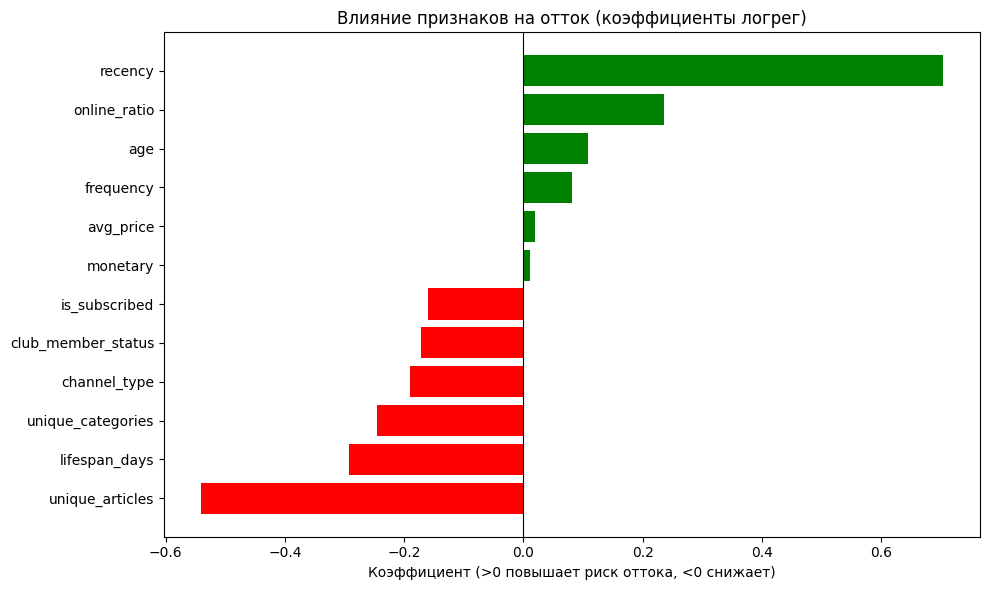

,feature,coefficient
0,recency,0.703765
4,unique_articles,-0.540392
6,lifespan_days,-0.291981
5,unique_categories,-0.245048
7,online_ratio,0.235111
8,channel_type,-0.189667
10,club_member_status,-0.171332
11,is_subscribed,-0.160555
9,age,0.108362
1,frequency,0.081585


In [ ]:
coef = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': logreg.coef_[0]
}).sort_values('coefficient')

colors = ['green' if c > 0 else 'red' for c in coef['coefficient']]

plt.figure(figsize=(10, 6))
plt.barh(coef['feature'], coef['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Влияние признаков на отток (коэффициенты логрег)')
plt.xlabel('Коэффициент (>0 повышает риск оттока, <0 снижает)')
plt.tight_layout()
plt.show()

coef['abs'] = coef['coefficient'].abs()
display(coef.sort_values('abs', ascending=False)[['feature', 'coefficient']])

**Драйверы оттока:**

Повышают риск ухода:
- **recency** (сильнейший фактор) — чем дольше клиент не покупал,
  тем выше вероятность полного ухода.
- **online_ratio** — преимущественно онлайн-поведение связано
  с более высоким оттоком.

Снижают риск (удерживают):
- **unique_articles** (сильнейший фактор удержания) — разнообразие
  покупок отражает глубину вовлечённости.
- **lifespan_days, unique_categories** — длительная история и широта
  покупательского профиля.
- **club_member_status, is_subscribed** — вовлечённость в программы
  лояльности снижает отток (умеренно).

Frequency и monetary показали near-zero коэффициенты из-за
мультиколлинеарности с unique_articles и lifespan — их предсказательная
сила поглощена коррелирующими признаками, а не отсутствует.

**Вывод для бизнеса:** ключевые рычаги удержания — стимулировать
повторные покупки (снижать recency) и расширять разнообразие покупок
(кросс-категорийные предложения). Членство в клубе помогает,
но вторично по сравнению с поведенческими факторами.

## 6. Lift на топ-10% — бизнес-применение модели

Lift показывает эффективность таргетинга по модели. Клиенты сортируются
по предсказанному риску оттока, берётся топ-10% самых рисковых. Lift —
во сколько раз концентрация реально ушедших в этой группе выше, чем
в среднем по базе.

Метрика отвечает на практический вопрос: насколько эффективнее направить
ограниченный retention-бюджет на топ-10% по модели, чем на случайную выборку.

In [ ]:
results = pd.DataFrame({
    'churn_actual': y_test.values,
    'churn_proba': y_pred_proba_lr
}).sort_values('churn_proba', ascending=False).reset_index(drop=True)

churn_rate_base = results['churn_actual'].mean()

deciles = []
for d in range(1, 11):
    n = int(len(results) * d / 10)
    top = results.head(n)
    rate = top['churn_actual'].mean()
    deciles.append({
        'decile': f'Топ-{d*10}%',
        'churn_rate': round(rate*100, 1),
        'lift': round(rate / churn_rate_base, 2),
        'captured_pct': round(top['churn_actual'].sum() / results['churn_actual'].sum() * 100, 1)
    })

lift_df = pd.DataFrame(deciles)
display(lift_df)

top10 = lift_df.iloc[0]
print(f"\nТоп-10% по риску:")
print(f"  Churn rate: {top10['churn_rate']}% (база: {churn_rate_base*100:.1f}%)")
print(f"  Lift: {top10['lift']}")
print(f"  Покрытие: {top10['captured_pct']}% всех ушедших в 10% базы")

,decile,churn_rate,lift,captured_pct
0,Топ-10%,94.9,1.50,15.0
1,Топ-20%,93.6,1.48,29.6
2,Топ-30%,91.9,1.45,43.5
3,Топ-40%,89.8,1.42,56.7
4,Топ-50%,86.9,1.37,68.6
5,Топ-60%,83.2,1.31,78.8
6,Топ-70%,78.8,1.24,87.1
7,Топ-80%,74.1,1.17,93.6
8,Топ-90%,68.9,1.09,98.0
9,Топ-100%,63.3,1.00,100.0



Топ-10% по риску:
  Churn rate: 94.9% (база: 63.3%)
  Lift: 1.5
  Покрытие: 15.0% всех ушедших в 10% базы


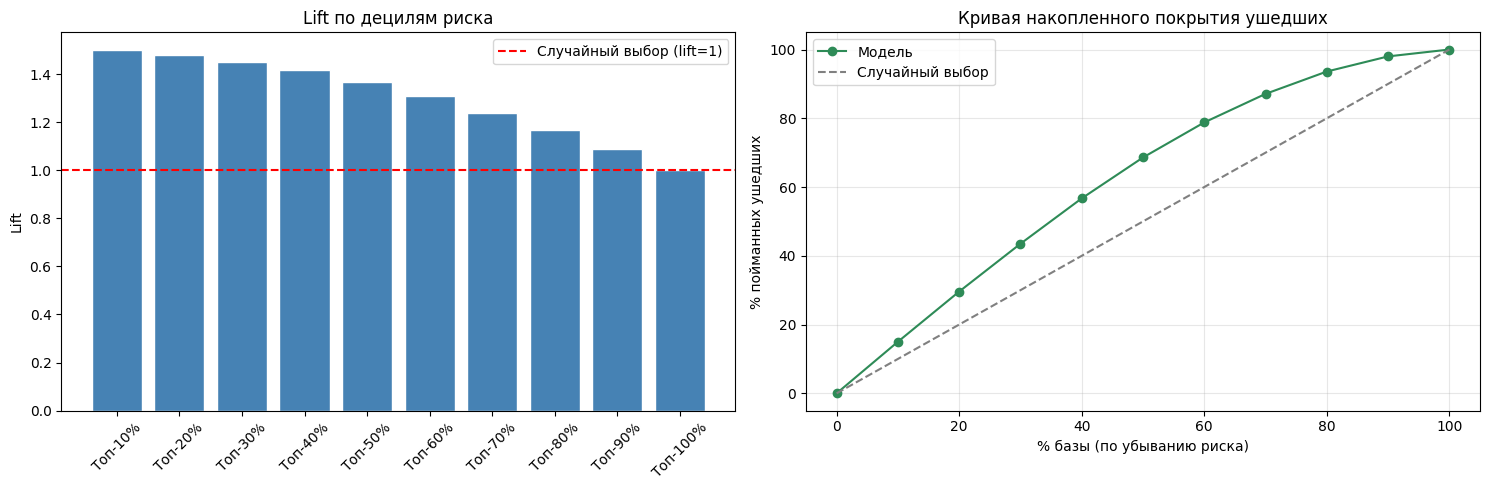

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].bar(lift_df['decile'], lift_df['lift'], color='steelblue', edgecolor='white')
ax[0].axhline(1, color='red', linestyle='--', label='Случайный выбор (lift=1)')
ax[0].set_title('Lift по децилям риска')
ax[0].set_ylabel('Lift')
ax[0].tick_params(axis='x', rotation=45)
ax[0].legend()

x = [0] + [d*10 for d in range(1, 11)]
y = [0] + list(lift_df['captured_pct'])
ax[1].plot(x, y, marker='o', color='seagreen', label='Модель')
ax[1].plot([0, 100], [0, 100], linestyle='--', color='gray', label='Случайный выбор')
ax[1].set_title('Кривая накопленного покрытия ушедших')
ax[1].set_xlabel('% базы (по убыванию риска)')
ax[1].set_ylabel('% пойманных ушедших')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Результаты применения модели:**

| Дециль | Churn rate | Lift | Покрытие ушедших |
|---|---|---|---|
| Топ-10% | 94.9% | 1.50 | 15.0% |
| Топ-30% | 91.9% | 1.45 | 43.5% |
| Топ-50% | 86.9% | 1.37 | 68.6% |

- Lift топ-10% = 1.5 — близко к математическому потолку (100/63 ≈ 1.58
  при базовом churn 63%). Модель почти идеально ранжирует в верхнем дециле.
- Покрытие в топ-децилях ограничено высокой долей оттока в базе:
  ушедших слишком много, чтобы уместить большинство в малую долю клиентов.
- Gain curve устойчиво выше диагонали — модель эффективнее случайного
  таргетинга на всём диапазоне.

**Вывод для бизнеса:**
Модель применима для приоритизации retention-бюджета по убыванию риска.
Однако при churn rate 63% ключевую ценность несут не предсказания, а
драйверы оттока (из анализа коэффициентов): главные рычаги удержания —
снижение recency (стимулирование повторных покупок) и рост разнообразия
покупок (кросс-категорийные предложения). Членство в клубе помогает вторично.

## Итоги Блока 5 (churn-модель)

1. Построена модель прогноза оттока (churn = нет покупок 3 месяца),
   с защитой от data leakage через разделение окон признаков и target.
2. Логистическая регрессия (ROC-AUC 0.833) и градиентный бустинг (0.841)
   показали сопоставимое качество. Малый прирост бустинга указывает
   на линейный характер зависимостей → для продакшена выбрана
   интерпретируемая логистическая регрессия.
3. Ключевые драйверы оттока: recency (повышает риск) и разнообразие
   покупок (снижает). Гипотеза Г3 подтверждена: членство в клубе
   снижает отток, но вторично по сравнению с поведением.
4. Lift топ-10% = 1.5 (близко к потолку при churn 63%) — модель
   применима для приоритизации retention-кампаний.

Связь с проектом: использованы фичи из RFM (Блок 2) и каналов (Блок 3),
подтверждена гипотеза о роли клубного членства из EDA.